<a href="https://colab.research.google.com/github/Rimsha35/Dev-Valley-AI-course/blob/Deep-learning-Assignments/wildlife_binary_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import tensorflow as tf
from tensorflow import keras
from collections import Counter
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [58]:
data = tf.keras.utils.image_dataset_from_directory("/content/drive/MyDrive/lion_tiger_dataset", labels="inferred", image_size=image_size, batch_size=batch_size)

Found 460 files belonging to 2 classes.


In [59]:
image_size = (224, 224)
batch_size = 32

In [60]:
dataset_size = len(data)

dataset_size

15

In [61]:
train_size = int(0.7 * dataset_size)

val_size =  int(0.2 * dataset_size)

test_size = int(0.1 * dataset_size)

In [62]:
train_size

10

In [63]:
train_data = data.take(train_size)
val_data = data.skip(train_size).take(val_size)
test_data = data.skip(train_size + val_size).take(test_size)

In [64]:
val_data

<_TakeDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [65]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1)
])

In [66]:
base_model = tf.keras.applications.MobileNet(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False   # freeze

In [67]:
model = tf.keras.Sequential([
    data_augmentation,   # only affects training
    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(1, activation='sigmoid')  # 1 output for binary classification
])

In [68]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [69]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [70]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_model.keras',  # Path to save the model
    monitor='val_loss',          # Metric to monitor
    save_best_only=True,         # Save only the best model
    verbose=1                    # Log messages when saving
)

In [71]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=[early_stop]

)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 53s 5s/step - accuracy: 0.5531 - loss: 0.8635 - val_accuracy: 0.5938 - val_loss: 0.6422
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.7188 - loss: 0.5383 - val_accuracy: 0.8333 - val_loss: 0.4138
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.7688 - loss: 0.4374 - val_accuracy: 0.8229 - val_loss: 0.3567
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.8313 - loss: 0.3834 - val_accuracy: 0.8438 - val_loss: 0.3765
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.8000 - loss: 0.3811 - val_accuracy: 0.8646 - val_loss: 0.3823
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.8438 - loss: 0.3814 - val_accuracy: 0.8438 - val_loss: 0.3418
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.8219 - loss: 0.3918 - val_accuracy: 0.8229 - val_loss: 0.3831
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.8250 - loss: 0.3611 - val_accuracy: 0.8438 - val_loss:

In [84]:
model.evaluate(test_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.9375 - loss: 0.1866


[0.18663159012794495, 0.9375]

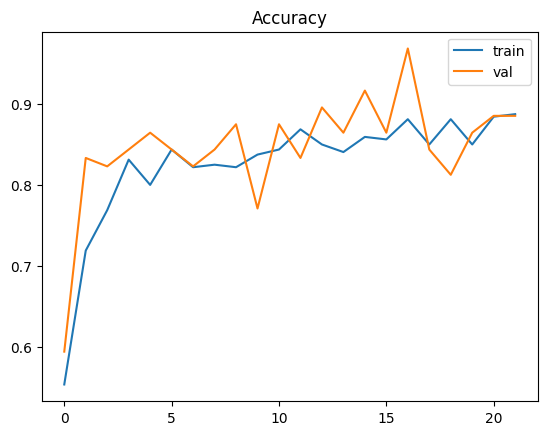

In [85]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


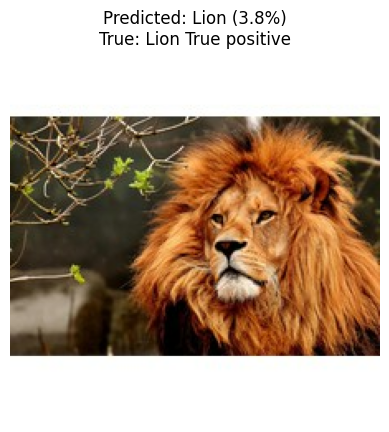

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


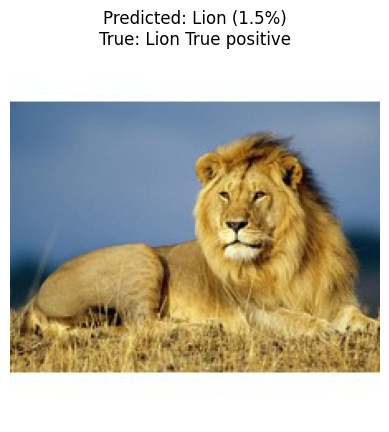

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


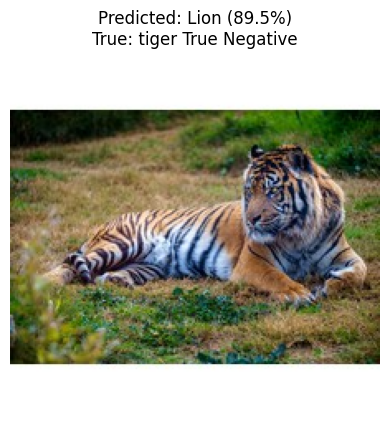

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


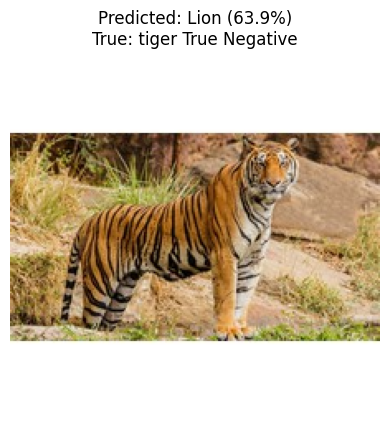

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


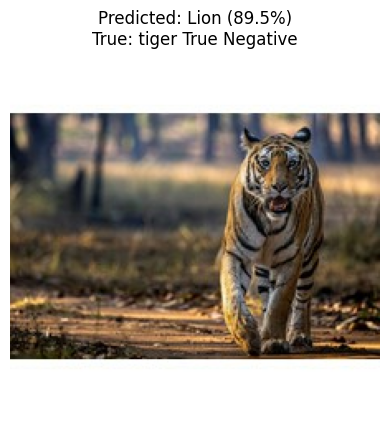

In [89]:
import matplotlib.pyplot as plt
import numpy as np

class_names = data.class_names  # labels (e.g., ['animal', 'human'])

# Take one batch from test data
for images, labels in test_data.take(1):

    for i in range(5):   # take 5 images

        img = images[i]
        true_label = class_names[int(labels[i])]

        # Model prediction
        pred = model.predict(tf.expand_dims(img, axis=0))
        pred_label_index = np.argmax(pred)
        pred_label = class_names[pred_label_index]
        confidence = np.max(pred) * 100

        # Show image
        plt.imshow(img.numpy().astype("uint8"))
        plt.axis('off')

        # Title with result
        result = "True positive" if pred_label == true_label else "True Negative"

        plt.title(f"Predicted: {pred_label} ({confidence:.1f}%)\nTrue: {true_label} {result}")
        plt.show()

In [90]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,622,853 (13.82 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

 Optimizer params: 262,660 (1.00 MB)